Mounted at /content/drive

Feature Importance

                        Feature       FI
4                     src_bytes 0.372003
1                 protocol_type 0.130985
41                   difficulty 0.055500
22                        count 0.054834
40     dst_host_srv_rerror_rate 0.052022
5                     dst_bytes 0.045615
32           dst_host_srv_count 0.035928
11                    logged_in 0.035821
29                diff_srv_rate 0.035287
35  dst_host_same_src_port_rate 0.018497
9                           hot 0.017645
38     dst_host_srv_serror_rate 0.015433
37         dst_host_serror_rate 0.014600
33       dst_host_same_srv_rate 0.014442
15                     num_root 0.014327
6                          land 0.012565
25              srv_serror_rate 0.009358
7                wrong_fragment 0.008815
12              num_compromised 0.007681
24                  serror_rate 0.007558
28                same_srv_rate 0.006640
3                          flag 0.006111
26        

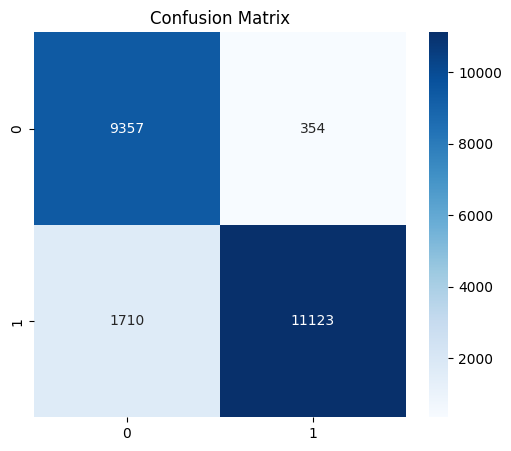


Computing SHAP...


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_208
Received: inputs=['Tensor(shape=(1, 22, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_208
Received: inputs=['Tensor(shape=(50, 22, 1))']
  warnings.warn(msg)
/tmp/ipykernel_780/2861059058.py:279: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


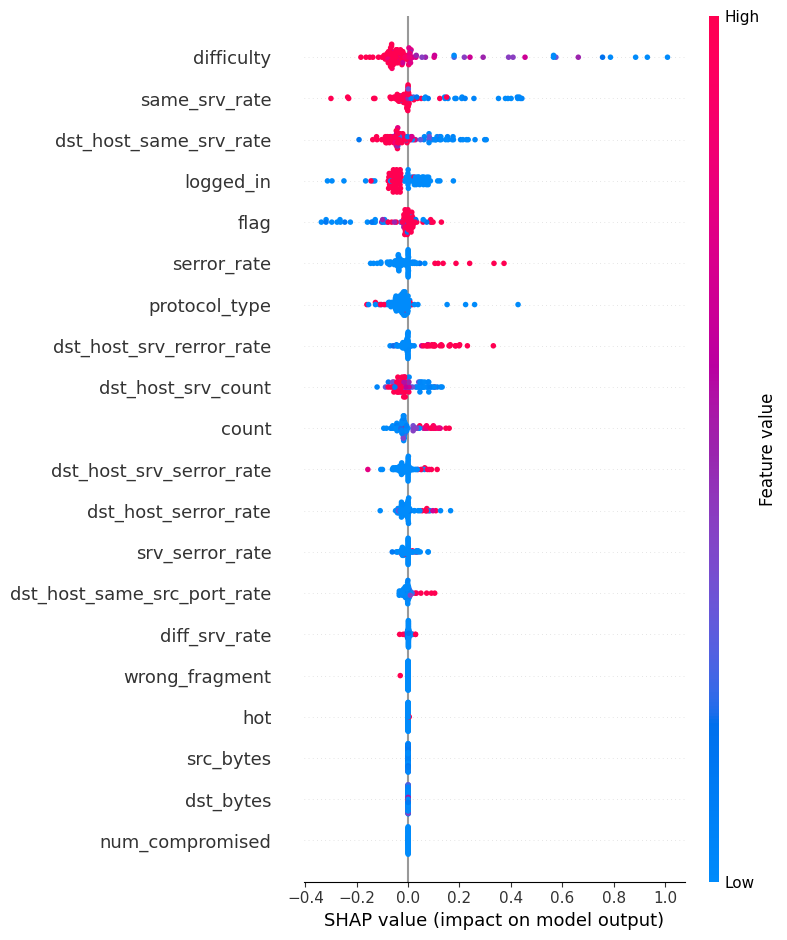

In [1]:
# =========================================================
# FINAL SIMPLE RNN (BIDIRECTIONAL + ATTENTION + S2/R2 + SHAP FIX)
# =========================================================

import pandas as pd
import numpy as np
import tensorflow as tf
import random
import time
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.utils import resample

from xgboost import XGBClassifier

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, SimpleRNN, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from google.colab import drive

# =========================================================
# SETUP
# =========================================================
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

pd.set_option('display.float_format', '{:.6f}'.format)

drive.mount('/content/drive')
base="/content/drive/MyDrive/NSL-KDD/"

# =========================================================
# LOAD DATA
# =========================================================
train_df=pd.read_csv(base+"KDDTrain.csv")
test_df=pd.read_csv(base+"KDDTest+.csv")

train_df['label']=train_df['label'].str.replace('.','',regex=False)
test_df['label']=test_df['label'].str.replace('.','',regex=False)

train_df['label']=np.where(train_df['label']=="normal",0,1)
test_df['label']=np.where(test_df['label']=="normal",0,1)

# =========================================================
# BALANCING
# =========================================================
df_normal=train_df[train_df.label==0]
df_attack=train_df[train_df.label==1]

df_attack=resample(df_attack,replace=True,n_samples=len(df_normal),random_state=42)
train_df=pd.concat([df_normal,df_attack])

# =========================================================
# SPLIT
# =========================================================
train_split,val_df=train_test_split(
    train_df,
    test_size=0.25,
    stratify=train_df['label'],
    random_state=42
)

# =========================================================
# PREPROCESS
# =========================================================
def preprocess(df_train,df_val,df_test):

    X_train=df_train.drop("label",axis=1)
    y_train=df_train["label"]

    X_val=df_val.drop("label",axis=1)
    y_val=df_val["label"]

    X_test=df_test.drop("label",axis=1)
    y_test=df_test["label"]

    cat_cols=["protocol_type","service","flag"]

    for col in cat_cols:
        le=LabelEncoder()
        all_vals=pd.concat([X_train[col],X_val[col],X_test[col]])
        le.fit(all_vals)

        X_train[col]=le.transform(X_train[col])
        X_val[col]=le.transform(X_val[col])
        X_test[col]=le.transform(X_test[col])

    scaler=MinMaxScaler()

    X_train=scaler.fit_transform(X_train)
    X_val=scaler.transform(X_val)
    X_test=scaler.transform(X_test)

    return X_train,X_val,X_test,y_train,y_val,y_test

X_train,X_val,X_test,y_train,y_val,y_test=preprocess(train_split,val_df,test_df)

# =========================================================
# XGBOOST FEATURE IMPORTANCE
# =========================================================
print("\nFeature Importance\n")

xgb=XGBClassifier(n_estimators=200,max_depth=6)
xgb.fit(X_train,y_train)

feature_names=train_split.drop("label",axis=1).columns

feature_table=pd.DataFrame({
    "Feature":feature_names,
    "FI":xgb.feature_importances_
}).sort_values("FI",ascending=False)

print(feature_table)

# =========================================================
# TOP 22 FEATURES
# =========================================================
optimal_features=feature_table.head(22)

print("\nTop 22 Features\n")
print(optimal_features)

idx=[list(feature_names).index(f) for f in optimal_features["Feature"]]

X_train=X_train[:,idx]
X_val=X_val[:,idx]
X_test=X_test[:,idx]

# =========================================================
# RESHAPE
# =========================================================
X_train=X_train.reshape(-1,len(idx),1)
X_val=X_val.reshape(-1,len(idx),1)
X_test=X_test.reshape(-1,len(idx),1)

# =========================================================
# MODEL
# =========================================================
def build_model(nu, dense_type):

    inputs = Input(shape=(len(idx),1))

    x = Bidirectional(SimpleRNN(nu, return_sequences=True))(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    x = Bidirectional(SimpleRNN(nu, return_sequences=True))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # Attention
    score = Dense(64, activation="tanh")(x)
    score = Dense(32, activation="tanh")(score)
    score = Dense(1)(score)

    weights = tf.keras.layers.Softmax(axis=1)(score)
    attn = tf.keras.layers.Multiply()([x, weights])
    attn = tf.keras.layers.GlobalAveragePooling1D()(attn)

    if dense_type == "R2":
        x = Dense(nu//2, activation="relu")(attn)
    else:
        x = Dense(nu//2, activation="sigmoid")(attn)

    x = Dropout(0.3)(x)

    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

# =========================================================
# TRAINING LOOP
# =========================================================
NU_list=[15,30,40,60,90,120,150]

results=[]
best_TAC=0

for nu in NU_list:
    for dense in ["S2","R2"]:

        print(f"Training NU={nu} Dense={dense}")

        model=build_model(nu,dense)

        early=EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

        start=time.time()

        history=model.fit(
            X_train,y_train,
            epochs=40,
            batch_size=128,
            validation_data=(X_val,y_val),
            callbacks=[early],
            verbose=0
        )

        Ts=time.time()-start
        VAC=max(history.history["val_accuracy"])

        probs=model.predict(X_test)

        best_acc=0

        for t in np.arange(0.05,0.95,0.01):
            preds=(probs>t).astype(int)
            acc=accuracy_score(y_test,preds)

            if acc>best_acc:
                best_acc=acc

        TAC=best_acc

        results.append([nu,3,dense,VAC,TAC,Ts])

        if TAC>best_TAC:
            best_TAC=TAC
            best_model=model

# =========================================================
# RESULTS TABLE
# =========================================================
results_df=pd.DataFrame(
    results,
    columns=["NU","HS","Dense","VAC","TAC","Ts"]
).sort_values("TAC",ascending=False)

print("\nFINAL RESULTS\n")
print(results_df)

print("\nBest TAC:",best_TAC)

# =========================================================
# CONFUSION MATRIX
# =========================================================
preds=(probs>0.5).astype(int)

cm=confusion_matrix(y_test,preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# =========================================================
# SHAP (FIXED)
# =========================================================
print("\nComputing SHAP...")

background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

explainer = shap.GradientExplainer(best_model, background)

shap_values_list = []

for i in range(X_test[:100].shape[0]):
    sample_shap_values = explainer.shap_values(X_test[i:i+1])
    shap_values_list.append(np.asarray(sample_shap_values[0]).squeeze())

shap_values = np.stack(shap_values_list, axis=0)

shap.summary_plot(
    shap_values,
    X_test[:100].squeeze(axis=-1),
    feature_names=optimal_features["Feature"].tolist()
)